In [1]:
from google.colab import files
uploaded = files.upload()

Saving q1_heart_disease.csv to q1_heart_disease.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('q1_heart_disease.csv')
df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


In [4]:
print("Shape of dataset:", df.shape)

print("\nData types:\n")
print(df.dtypes)

print("\nMissing values:\n")
print(df.isnull().sum())

Shape of dataset: (800, 12)

Data types:

age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing values:

age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


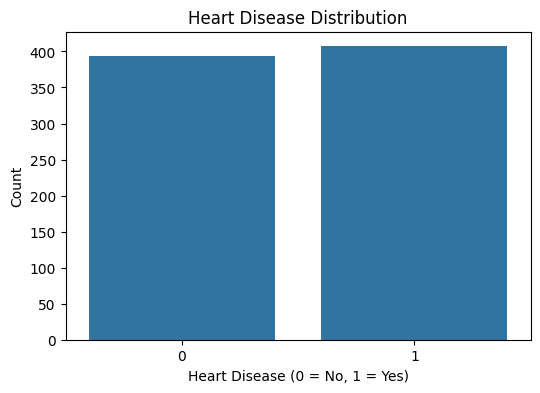

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='heart_disease')

plt.title('Heart Disease Distribution')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')

plt.show()

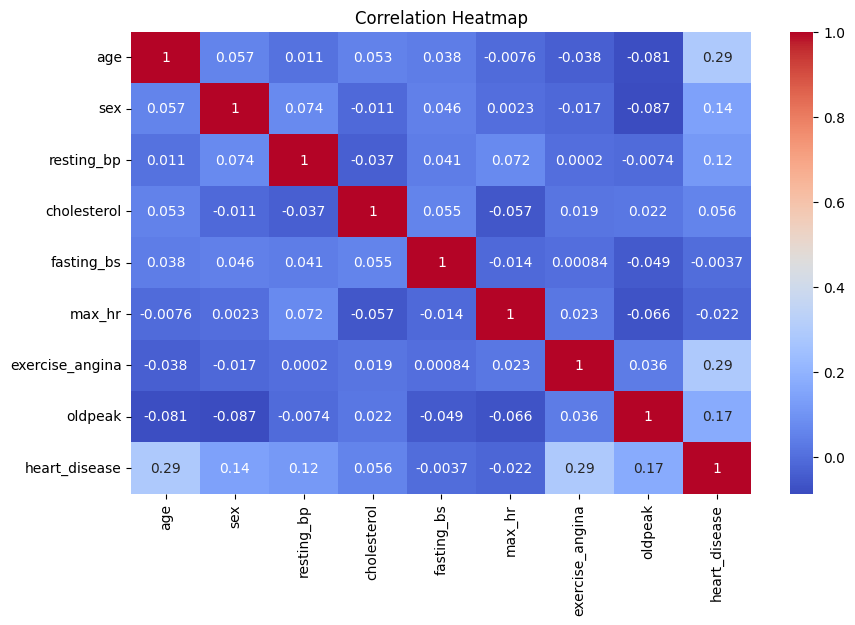

In [6]:
plt.figure(figsize=(10,6))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

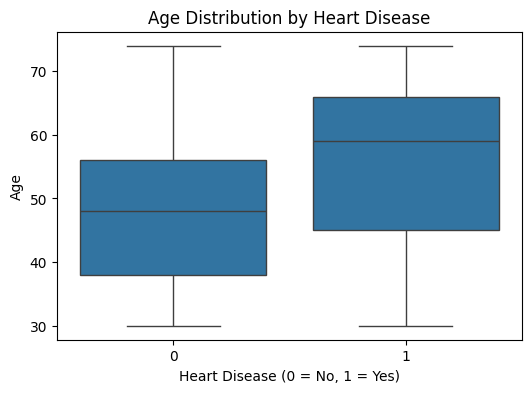

In [7]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='heart_disease', y='age')

plt.title('Age Distribution by Heart Disease')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Age')

plt.show()

In [8]:
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

In [9]:
print(X.head())
print(y.head())

   age  sex  chest_pain_type  resting_bp  cholesterol  fasting_bs  \
0   68    0  atypical_angina       142.0        399.0           0   
1   58    1      non_anginal       163.0        310.0           1   
2   44    1      non_anginal       128.0        175.0           0   
3   72    1     asymptomatic       114.0        177.0           0   
4   37    1      non_anginal       149.0        271.0           0   

                    resting_ecg  max_hr  exercise_angina  oldpeak st_slope  
0  left_ventricular_hypertrophy     169                0      0.4       up  
1         st_t_wave_abnormality     121                1      1.1       up  
2                        normal     183                1      0.2       up  
3         st_t_wave_abnormality     150                0      1.0       up  
4                        normal     136                0      0.4     flat  
0    1
1    1
2    0
3    1
4    0
Name: heart_disease, dtype: int64


In [10]:
categorical_cols = ['sex', 'chest_pain_type', 'fasting_bs', 'resting_ecg', 'exercise_angina', 'st_slope']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['sex', 'chest_pain_type', 'fasting_bs', 'resting_ecg', 'exercise_angina', 'st_slope']
Numerical columns: ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']


In [11]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [12]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [13]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (640, 11)
Test shape: (160, 11)


In [15]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

In [16]:
fitted_models = {}
predictions = {}

In [17]:
from sklearn.pipeline import Pipeline

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    fitted_models[name] = pipeline
    predictions[name] = y_pred

    print(f"{name} trained successfully.")

Decision Tree trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


In [18]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report

In [19]:
results = []

for name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    })

    print(f"\n{name}")
    print("-" * 40)
    print("Confusion Matrix:")
    print(cm)
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Decision Tree
----------------------------------------
Confusion Matrix:
[[58 21]
 [19 62]]
Precision: 0.7470
Recall:    0.7654
F1-score:  0.7561

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.73      0.74        79
           1       0.75      0.77      0.76        81

    accuracy                           0.75       160
   macro avg       0.75      0.75      0.75       160
weighted avg       0.75      0.75      0.75       160


Random Forest
----------------------------------------
Confusion Matrix:
[[63 16]
 [17 64]]
Precision: 0.8000
Recall:    0.7901
F1-score:  0.7950

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.80      0.79        79
           1       0.80      0.79      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Gra

In [20]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1-score', ascending=False)

results_df

,Model,Precision,Recall,F1-score
1,Random Forest,0.800000,0.790123,0.795031
2,Gradient Boosting,0.777778,0.777778,0.777778
0,Decision Tree,0.746988,0.765432,0.756098


In [ ]:
### Best Model Conclusion

The best model is selected based on F1-score, as it balances both precision and recall.

- Precision measures how many predicted positive cases are correct
- Recall measures how many actual positive cases are identified
- F1-score provides a balance between both

Based on the results above, the model with the highest F1-score is considered the best performing model.

In [21]:
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

In [22]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split': [2, 5]
}

In [23]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'resting_bp',
                                                                          'cholesterol',
                                                                          'max_hr',
                                                                          'oldpeak']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['sex',
                                                                          'chest_pain_type',
                                                                          'fasting_bs',
                                                                          'resting_ecg',
                                                                          'exercise_angina',
                                                                          'st_slope'])])),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 5, 10],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='f1')

In [24]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [25]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

In [ ]:
### Hyperparameter Tuning Results

GridSearchCV was used to tune the Random Forest model by testing multiple combinations of hyperparameters.

The best parameters found are shown above. The tuned model was evaluated on the test set using precision, recall, and F1-score.

The tuned model performance can now be compared with the original Random Forest model. If the F1-score improves, it indicates that tuning has improved the model. Otherwise, the original model may already have been close to optimal.